In [2]:
import pandas as pd
import os
import librosa as librs
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import pywt
import time
from pydub import AudioSegment
import soundfile as sf

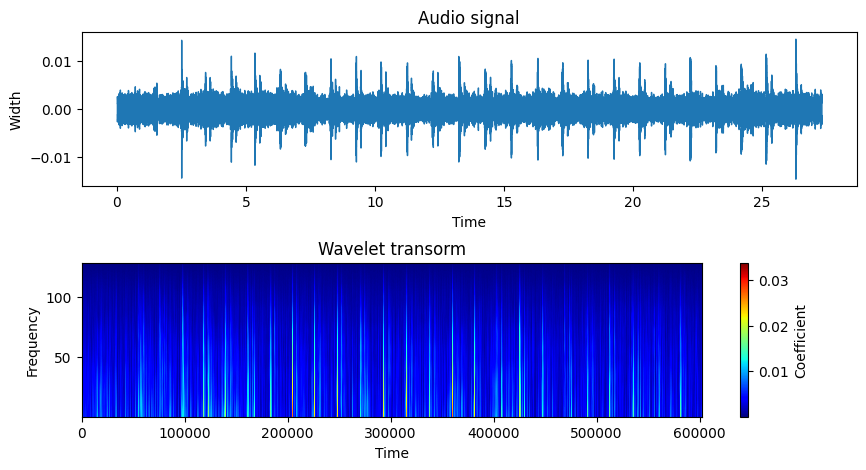

In [4]:
# Calcolo della trasformata wavelet
file_path = './archive/fold16/input/0.wav'
y, sr = librs.load(file_path)
# Set the start and end points for trimming
start_time = int(0.15 * sr)
end_time = int(len(y) - 0.15 * sr)
# Trim the audio
yc = y[start_time:end_time]

wavelet = 'cmor'  # Tipo di wavelet (può essere cambiato)
coefficients, frequencies = pywt.cwt(yc, np.arange(1, 128), wavelet)

# Visualizzazione del segnale audio e della trasformata wavelet
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
librs.display.waveshow(yc, sr=sr)
plt.ylabel('Width')
plt.title('Audio signal')

plt.subplots_adjust(hspace=0.5)

plt.subplot(2, 1, 2)
plt.imshow(np.abs(coefficients), extent=[0, len(yc), 1, 128], cmap='jet', aspect='auto')
plt.colorbar(label='Coefficient')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Wavelet transorm')
plt.savefig("results/0wav_1secs_17cm.png")
plt.show()

In [22]:
#tecnica di riconoscimento picchi 1: calcolo del rumore e poi considerare picco ciò che è x volte superiore
output_dir = "archive/fold16/output_directory"  # Replace with the path to your output directory
click_time = 0.5

def split_trim(input_file, peak_times, click_time, audio, sr):
    for t in range(len(peak_times)):
        print('########################################################')
        start_time = int((peak_times[t] - (click_time/2)) * sr)
        end_time = int((peak_times[t] + (click_time/2)) * sr)
        split_audio = audio[start_time:end_time]
        file_name_without_extension = os.path.splitext(os.path.basename(input_file))[0]
        output_filename = os.path.join(output_dir, f"{file_name_without_extension}_split_{t+1}.wav")
        sf.write(output_filename, split_audio, sr)
        print(f"Split {t+1} saved as {output_filename}")                       

def recognize_peak(file_path, y, sr):
    peak_times = []
    peak_recognize_scale = 2.5
    window_noise_calculation = 0.15
    # Calcolo della trasformata wavelet
    waveletname = 'cmor'  # Tipo di wavelet (può essere cambiato)
    scales = np.arange(1, 128)
    coefficients, frequencies = pywt.cwt(y, scales, waveletname)
    # Calcolo del "threshold" del rumore di fondo
    time_window = int(window_noise_calculation * sr)  # x secondi dai quali prendere il rumore di fondo
    noise_level = np.mean(np.abs(coefficients[:, :time_window]))
    noise_level = (noise_level+0.002)/2
    # Impostazione del "threshold" al x del rumore di fondo
    threshold = peak_recognize_scale * noise_level
    # Analisi della traccia e memorizzazione dei momenti in cui vengono trovati i picchi
    i = 0
    peak_count = 0
    maybe_peak = 0
    while i < len(coefficients[0]):
        peak_found = False
        for j in range(len(coefficients)):
            maybe_peak = abs(coefficients[j, i] - coefficients[j, i - 1])
            if i > 0 and maybe_peak > threshold :
                time_of_peak = librs.samples_to_time(i, sr=sr)  # Converte i campioni in tempo
                if(time_of_peak > 2):
                    peak_times.append(time_of_peak)
                    i += int(click_time * sr)  # Salta in avanti di x secondi
                    peak_found = True
                    peak_count+=1
                break
        if not peak_found:
            i += 1
    
    # Rappresentazione grafica dei picchi trovati sull'onda audio
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(y)) / sr, y, label='Audio wave')  # Grafico dell'onda audio
    # Indicazione dei picchi trovati sull'onda audio
    for peak_time in peak_times:
        plt.axvline(x=peak_time, color='red', linestyle='--', alpha=0.7)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Width')
    plt.title('Spikes on audio wave')
    plt.legend()
    plt.show()
    # Stampa del numero di picchi sopra il "threshold" e del rumore di fondo
    print(f"Valore del rumore di fondo: {noise_level}")
    print(f"Numero di picchi sopra il threshold: {peak_count}")
    split_trim(file_path, peak_times, click_time, y, sr)

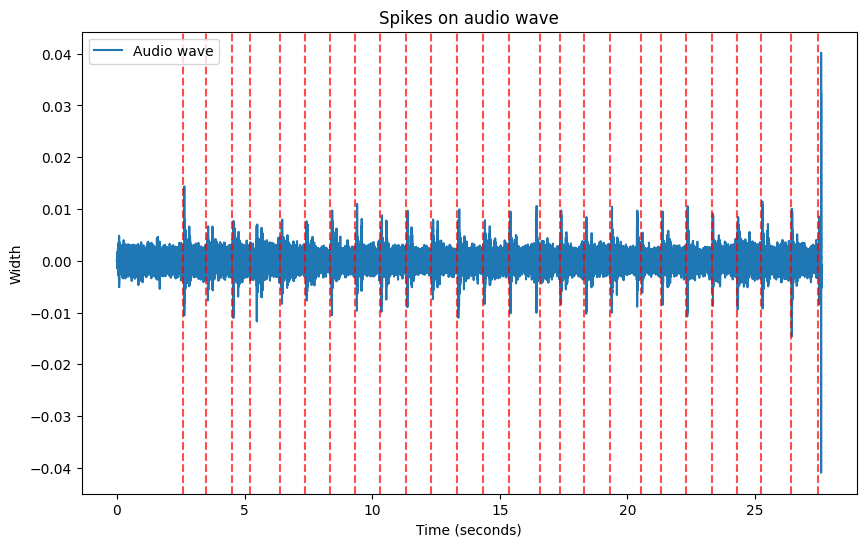

Valore del rumore di fondo: 0.0019501916356384754
Numero di picchi sopra il threshold: 26
########################################################
Split 1 saved as archive/fold16/output_directory\0_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\0_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\0_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\0_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\0_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\0_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\0_split_7.wav
########################################################
Split 8 saved

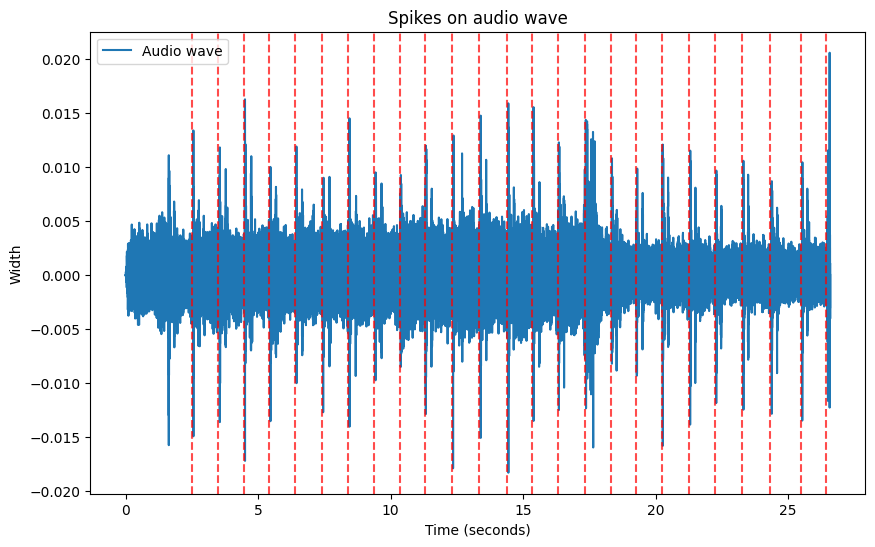

Valore del rumore di fondo: 0.002160442247055471
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\1_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\1_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\1_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\1_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\1_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\1_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\1_split_7.wav
########################################################
Split 8 saved 

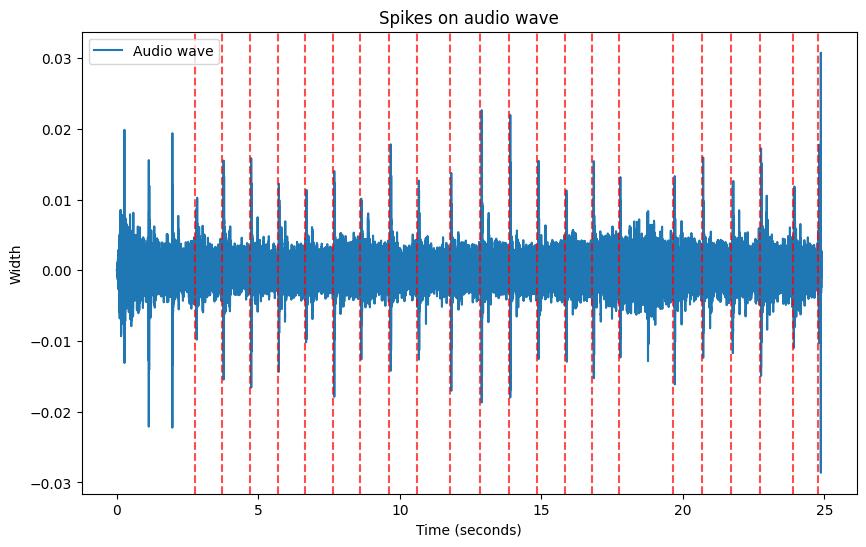

Valore del rumore di fondo: 0.0037998497243970633
Numero di picchi sopra il threshold: 22
########################################################
Split 1 saved as archive/fold16/output_directory\2_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\2_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\2_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\2_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\2_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\2_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\2_split_7.wav
########################################################
Split 8 saved

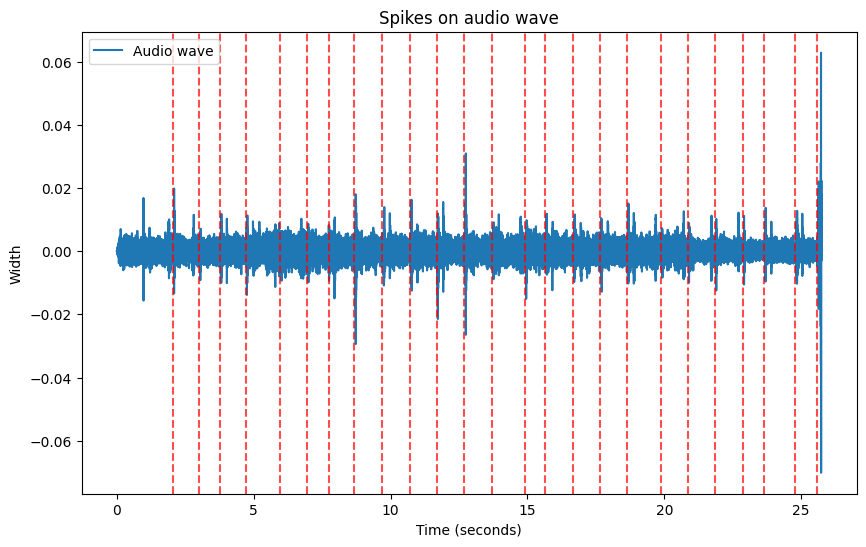

Valore del rumore di fondo: 0.0031401639096438885
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\3_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\3_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\3_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\3_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\3_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\3_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\3_split_7.wav
########################################################
Split 8 saved

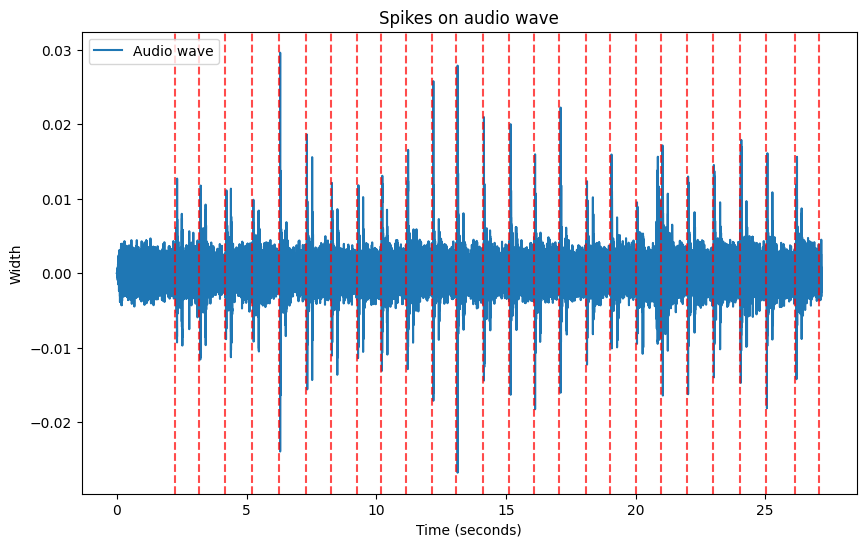

Valore del rumore di fondo: 0.002005551777780056
Numero di picchi sopra il threshold: 26
########################################################
Split 1 saved as archive/fold16/output_directory\4_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\4_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\4_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\4_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\4_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\4_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\4_split_7.wav
########################################################
Split 8 saved 

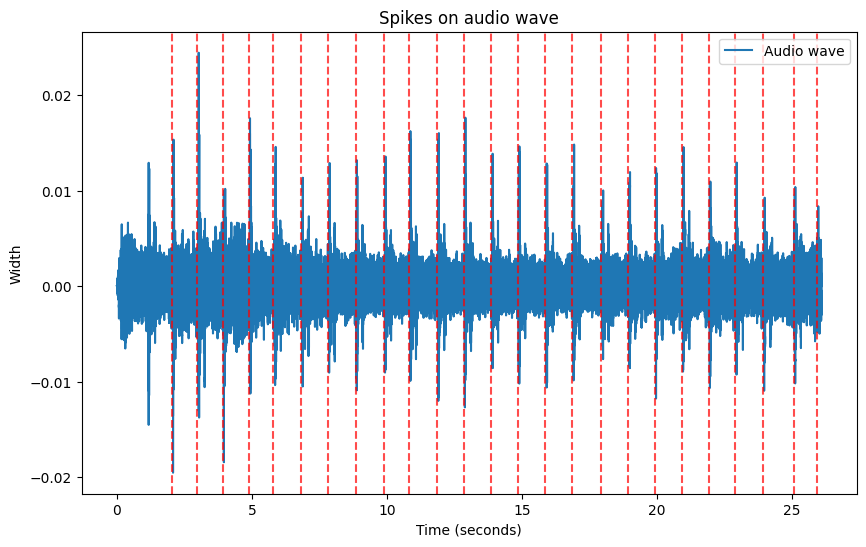

Valore del rumore di fondo: 0.001984777812846005
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\5_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\5_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\5_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\5_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\5_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\5_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\5_split_7.wav
########################################################
Split 8 saved 

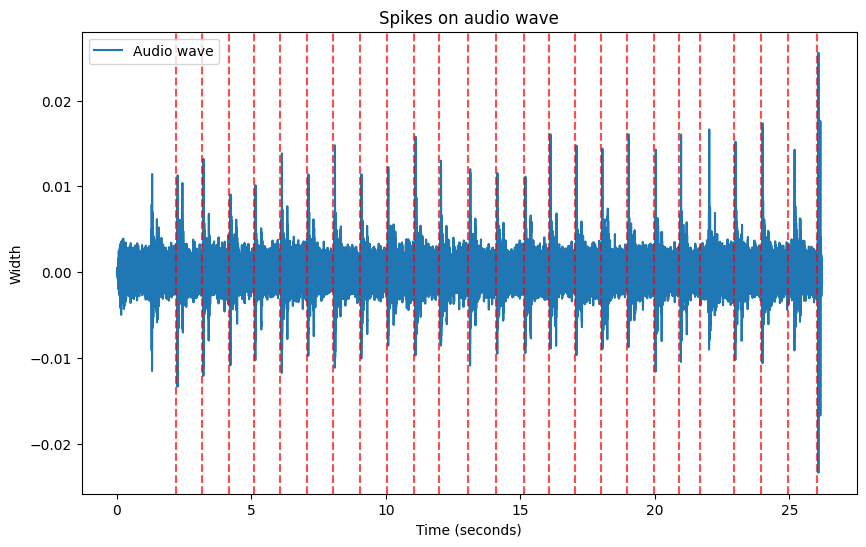

Valore del rumore di fondo: 0.0018344099042005837
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\6_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\6_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\6_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\6_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\6_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\6_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\6_split_7.wav
########################################################
Split 8 saved

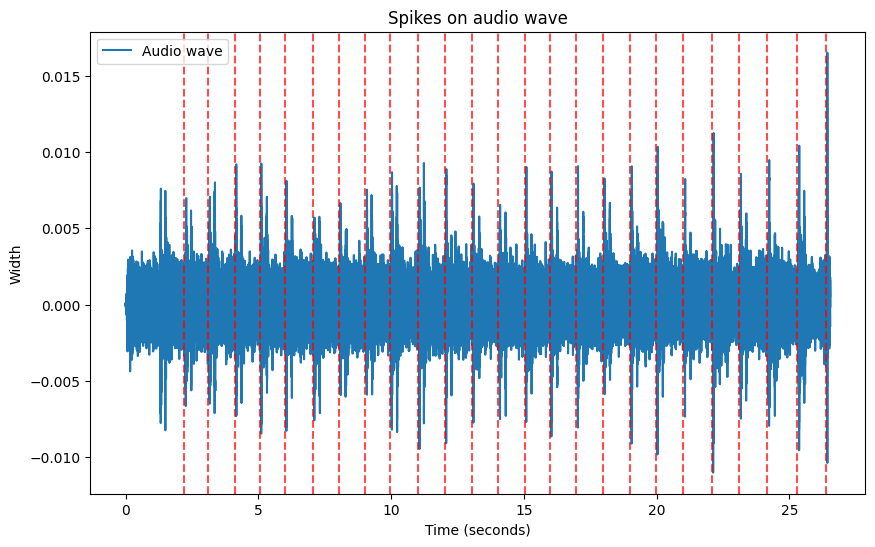

Valore del rumore di fondo: 0.0017822637562640012
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\7_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\7_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\7_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\7_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\7_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\7_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\7_split_7.wav
########################################################
Split 8 saved

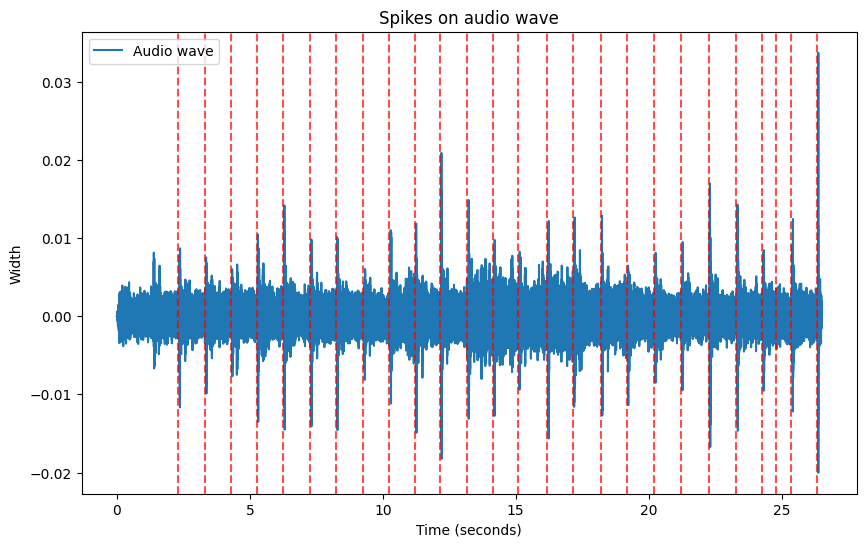

Valore del rumore di fondo: 0.001750662002246827
Numero di picchi sopra il threshold: 26
########################################################
Split 1 saved as archive/fold16/output_directory\8_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\8_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\8_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\8_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\8_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\8_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\8_split_7.wav
########################################################
Split 8 saved 

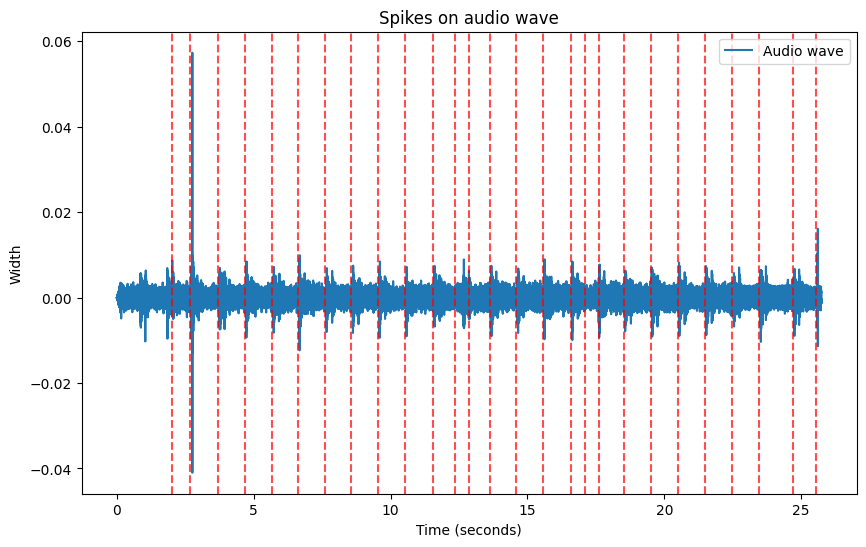

Valore del rumore di fondo: 0.0017729518110863865
Numero di picchi sopra il threshold: 27
########################################################
Split 1 saved as archive/fold16/output_directory\9_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\9_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\9_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\9_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\9_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\9_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\9_split_7.wav
########################################################
Split 8 saved

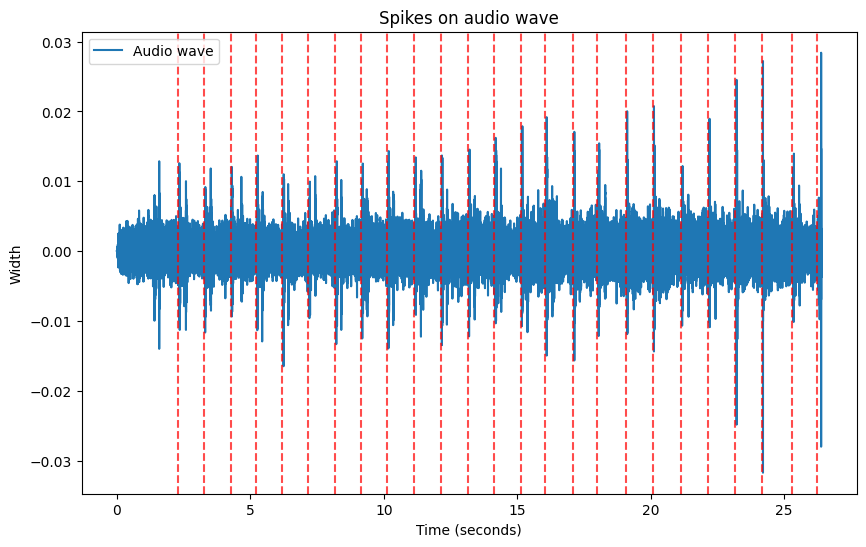

Valore del rumore di fondo: 0.00225418440438807
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\A_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\A_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\A_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\A_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\A_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\A_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\A_split_7.wav
########################################################
Split 8 saved a

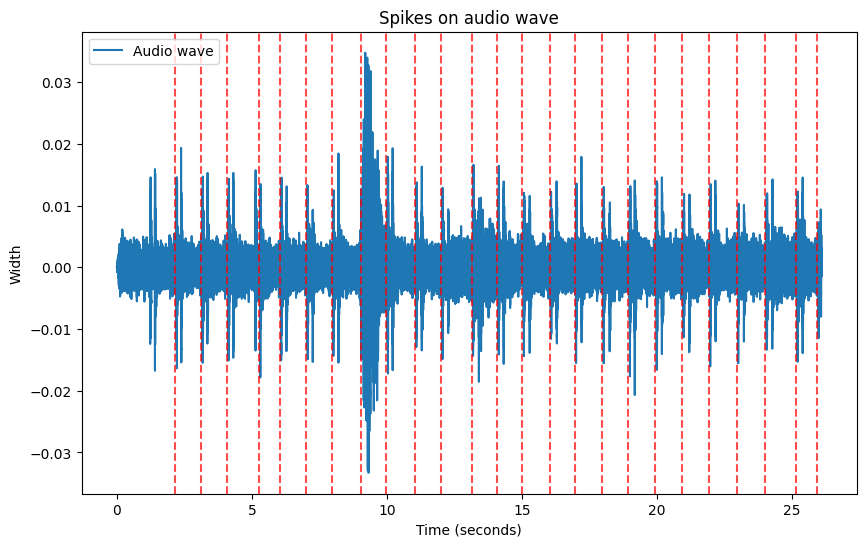

Valore del rumore di fondo: 0.0023391233514994383
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\B_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\B_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\B_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\B_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\B_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\B_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\B_split_7.wav
########################################################
Split 8 saved

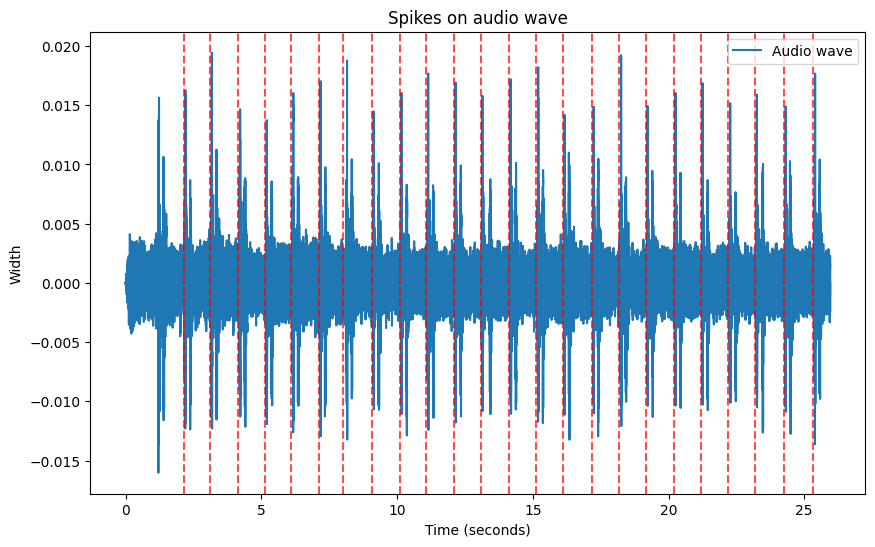

Valore del rumore di fondo: 0.001664405117277056
Numero di picchi sopra il threshold: 24
########################################################
Split 1 saved as archive/fold16/output_directory\C_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\C_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\C_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\C_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\C_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\C_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\C_split_7.wav
########################################################
Split 8 saved 

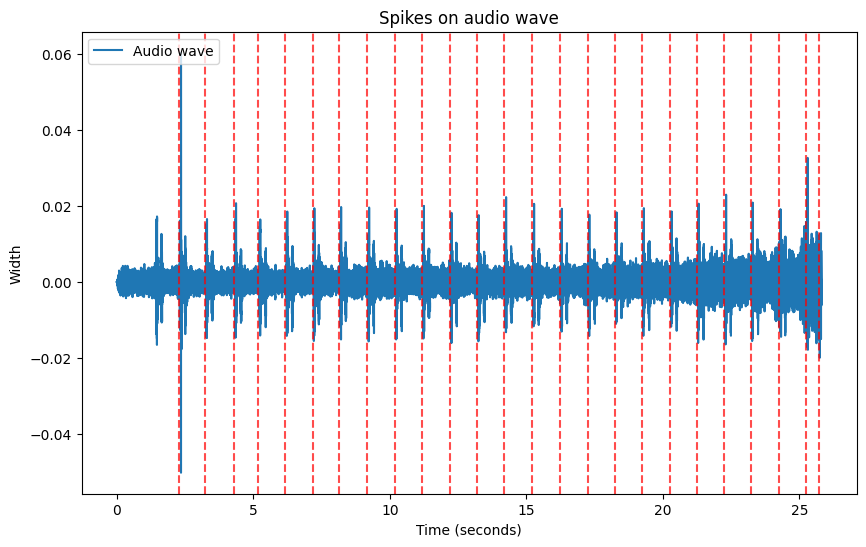

Valore del rumore di fondo: 0.002094910316169262
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\D_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\D_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\D_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\D_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\D_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\D_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\D_split_7.wav
########################################################
Split 8 saved 

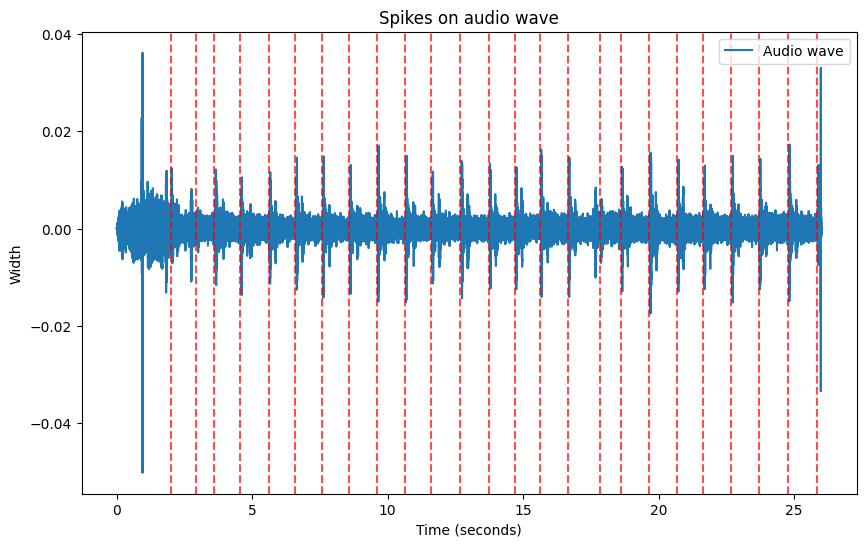

Valore del rumore di fondo: 0.002340454095043242
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\E_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\E_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\E_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\E_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\E_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\E_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\E_split_7.wav
########################################################
Split 8 saved 

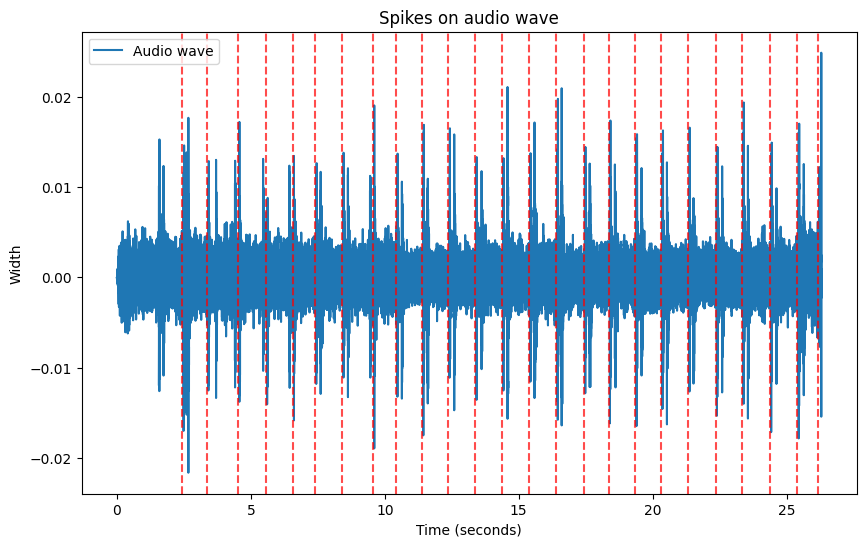

Valore del rumore di fondo: 0.0025182484639808536
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\F_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\F_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\F_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\F_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\F_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\F_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\F_split_7.wav
########################################################
Split 8 saved

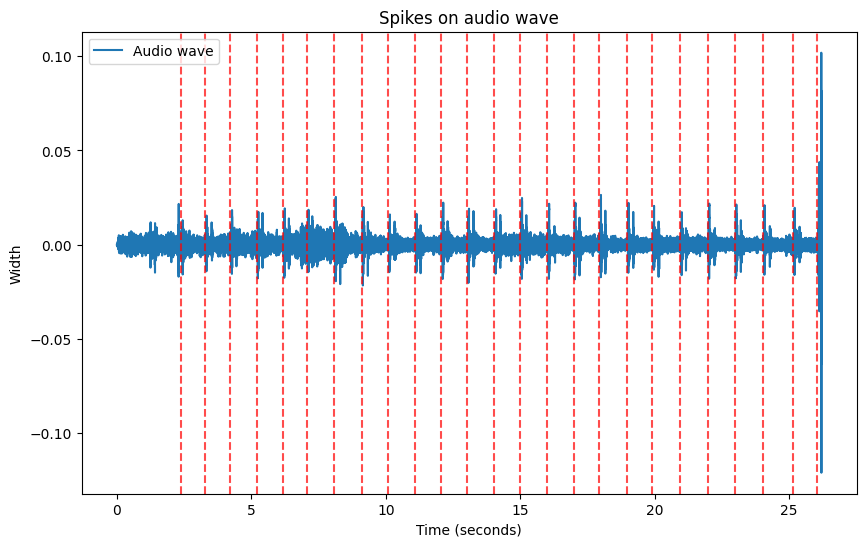

Valore del rumore di fondo: 0.003250183140859008
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\G_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\G_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\G_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\G_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\G_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\G_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\G_split_7.wav
########################################################
Split 8 saved 

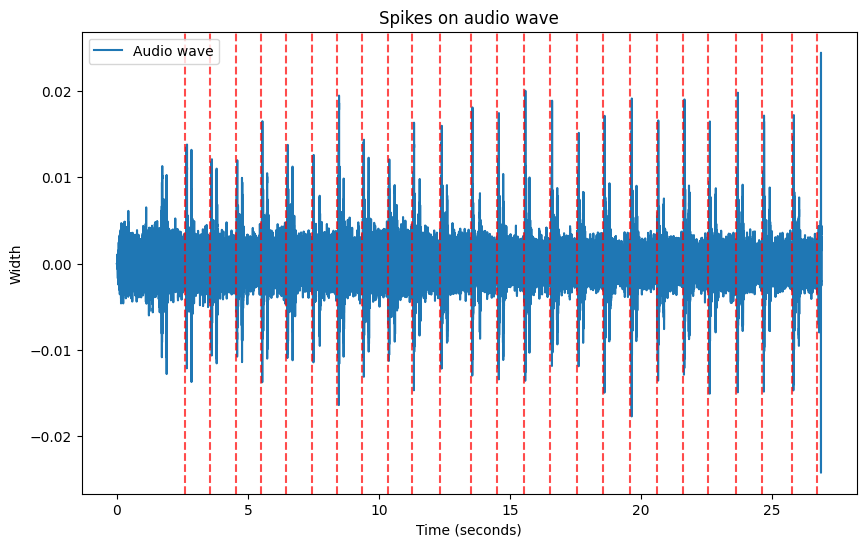

Valore del rumore di fondo: 0.00248412655107677
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\H_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\H_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\H_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\H_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\H_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\H_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\H_split_7.wav
########################################################
Split 8 saved a

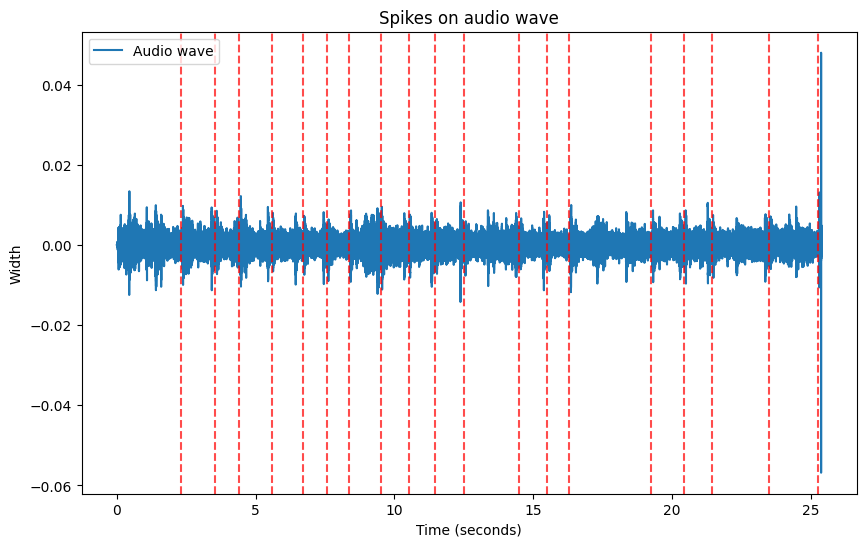

Valore del rumore di fondo: 0.0036192674413323403
Numero di picchi sopra il threshold: 19
########################################################
Split 1 saved as archive/fold16/output_directory\I_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\I_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\I_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\I_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\I_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\I_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\I_split_7.wav
########################################################
Split 8 saved

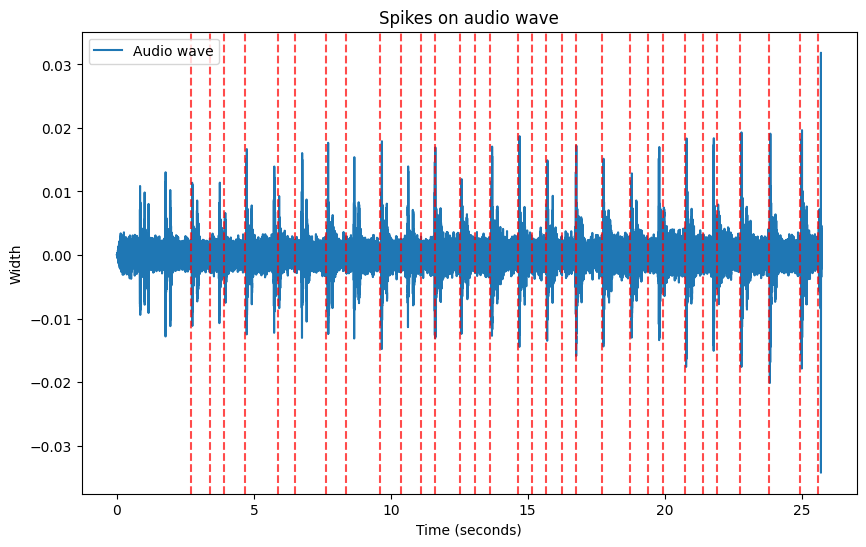

Valore del rumore di fondo: 0.0015685945507138968
Numero di picchi sopra il threshold: 31
########################################################
Split 1 saved as archive/fold16/output_directory\J_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\J_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\J_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\J_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\J_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\J_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\J_split_7.wav
########################################################
Split 8 saved

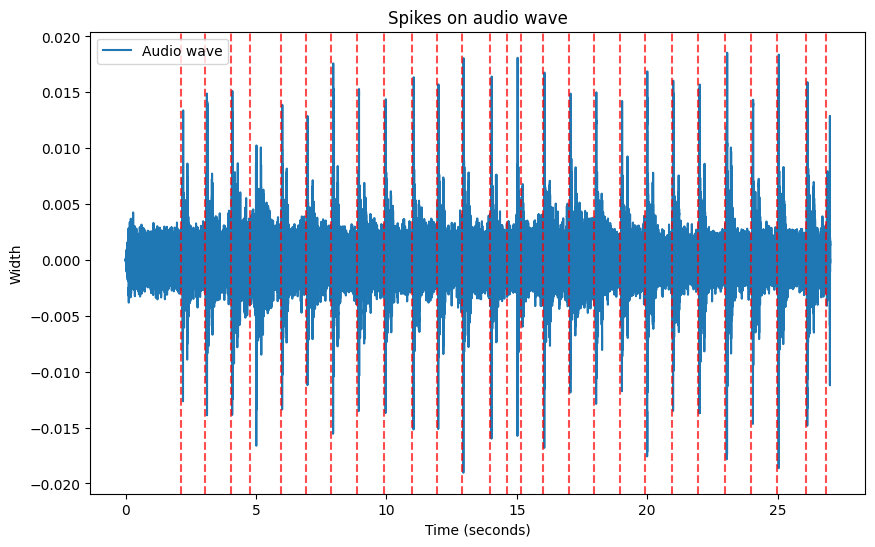

Valore del rumore di fondo: 0.001691401306539774
Numero di picchi sopra il threshold: 27
########################################################
Split 1 saved as archive/fold16/output_directory\K_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\K_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\K_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\K_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\K_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\K_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\K_split_7.wav
########################################################
Split 8 saved 

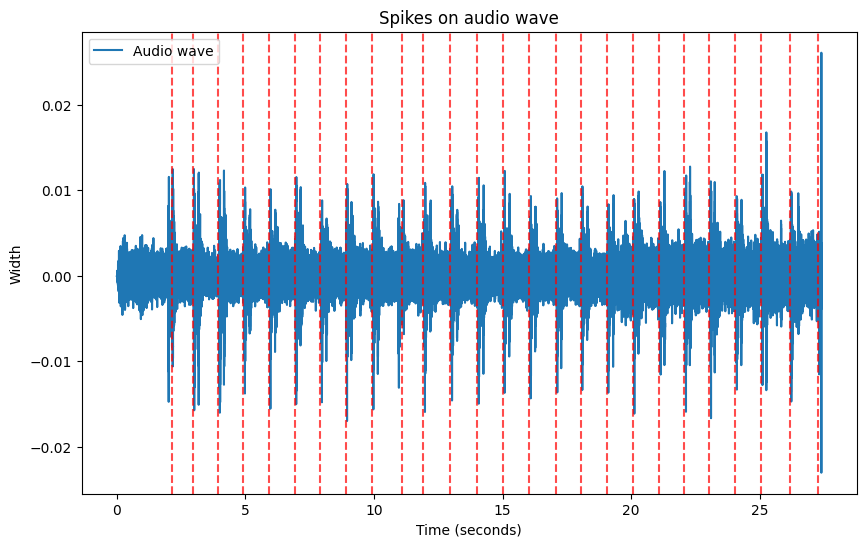

Valore del rumore di fondo: 0.0018649140945635736
Numero di picchi sopra il threshold: 26
########################################################
Split 1 saved as archive/fold16/output_directory\L_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\L_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\L_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\L_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\L_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\L_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\L_split_7.wav
########################################################
Split 8 saved

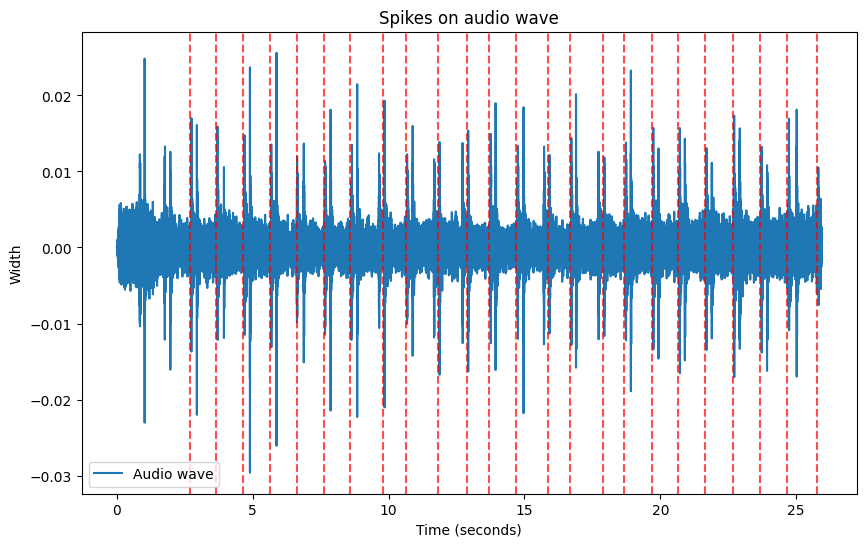

Valore del rumore di fondo: 0.0033024992551654577
Numero di picchi sopra il threshold: 24
########################################################
Split 1 saved as archive/fold16/output_directory\M_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\M_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\M_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\M_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\M_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\M_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\M_split_7.wav
########################################################
Split 8 saved

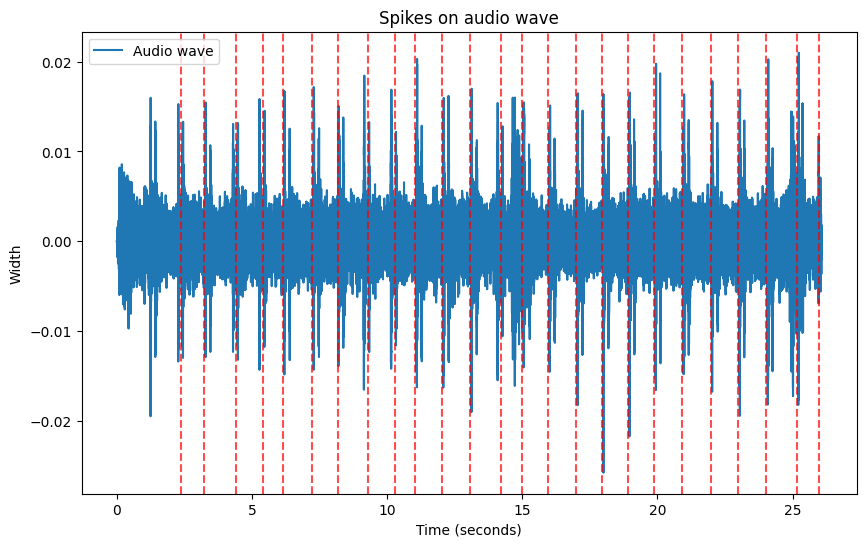

Valore del rumore di fondo: 0.0030828999113291502
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\N_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\N_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\N_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\N_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\N_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\N_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\N_split_7.wav
########################################################
Split 8 saved

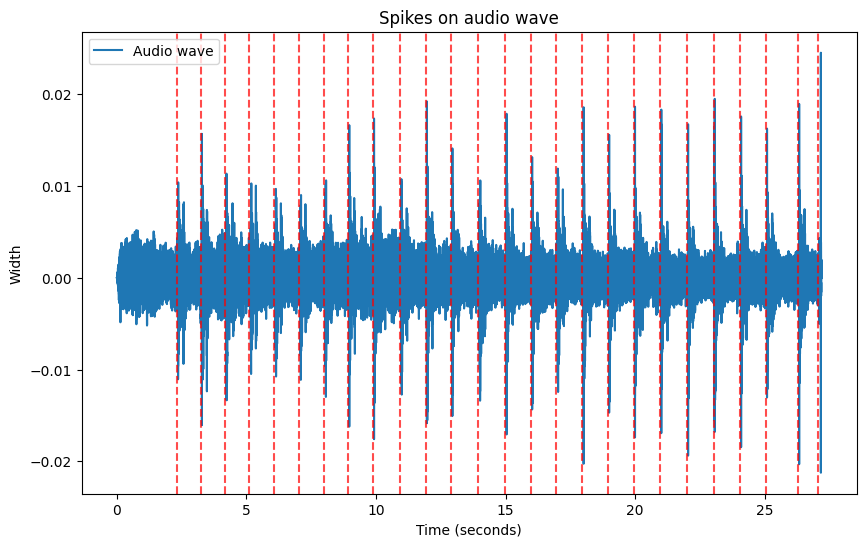

Valore del rumore di fondo: 0.00213617698661983
Numero di picchi sopra il threshold: 26
########################################################
Split 1 saved as archive/fold16/output_directory\O_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\O_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\O_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\O_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\O_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\O_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\O_split_7.wav
########################################################
Split 8 saved a

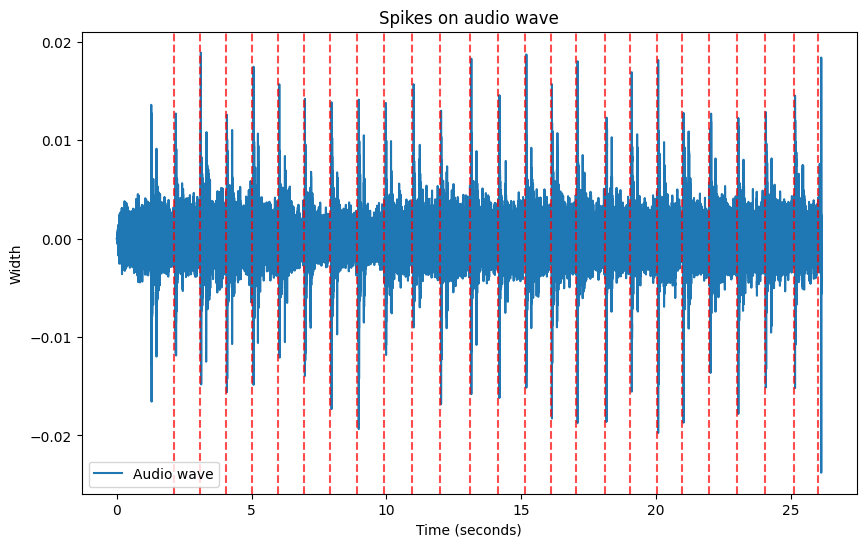

Valore del rumore di fondo: 0.0017807202637195587
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\P_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\P_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\P_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\P_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\P_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\P_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\P_split_7.wav
########################################################
Split 8 saved

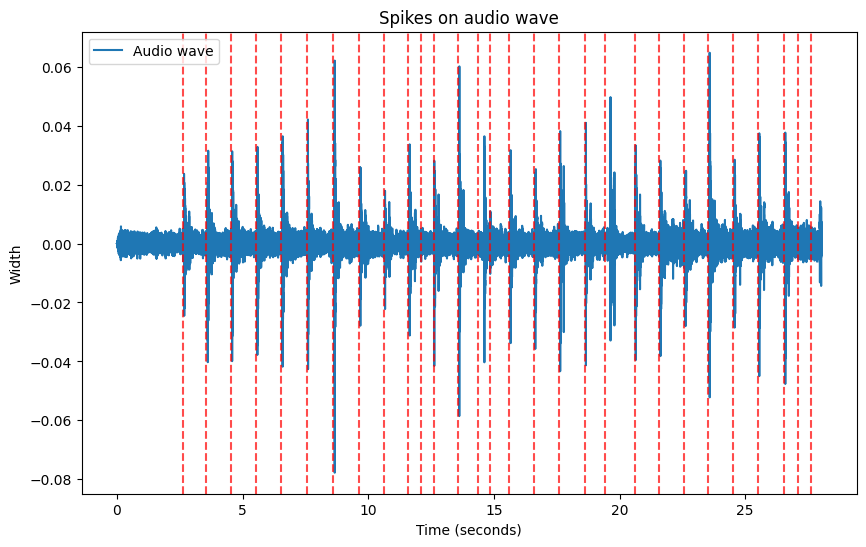

Valore del rumore di fondo: 0.0021557004181668163
Numero di picchi sopra il threshold: 29
########################################################
Split 1 saved as archive/fold16/output_directory\Q_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\Q_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\Q_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\Q_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\Q_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\Q_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\Q_split_7.wav
########################################################
Split 8 saved

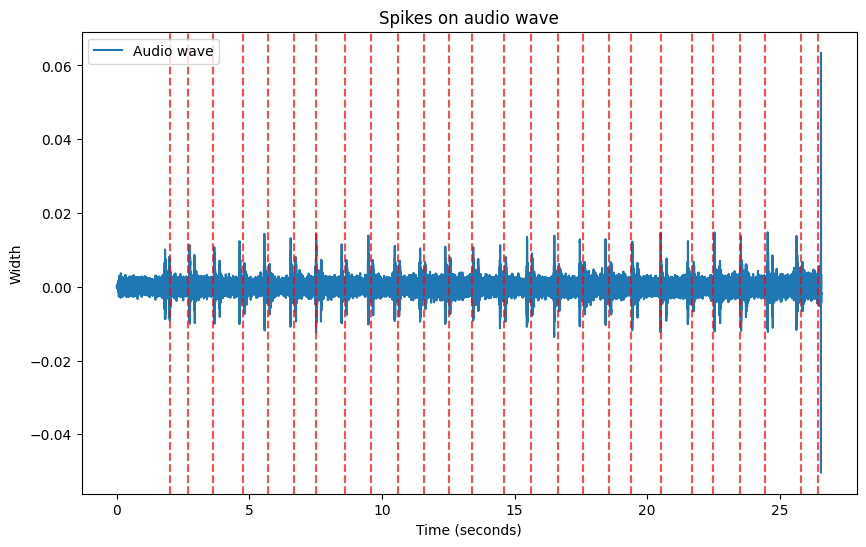

Valore del rumore di fondo: 0.0018922118577174843
Numero di picchi sopra il threshold: 26
########################################################
Split 1 saved as archive/fold16/output_directory\R_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\R_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\R_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\R_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\R_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\R_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\R_split_7.wav
########################################################
Split 8 saved

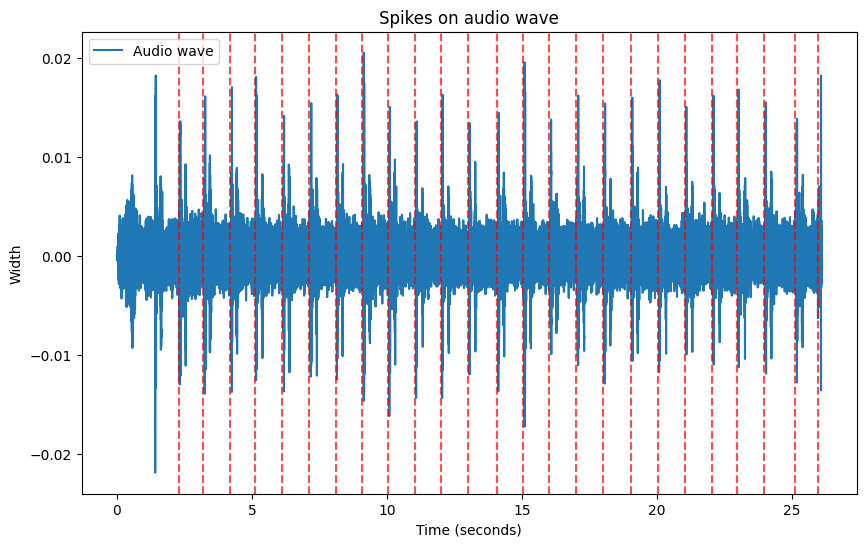

Valore del rumore di fondo: 0.0022117126025259495
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\S_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\S_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\S_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\S_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\S_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\S_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\S_split_7.wav
########################################################
Split 8 saved

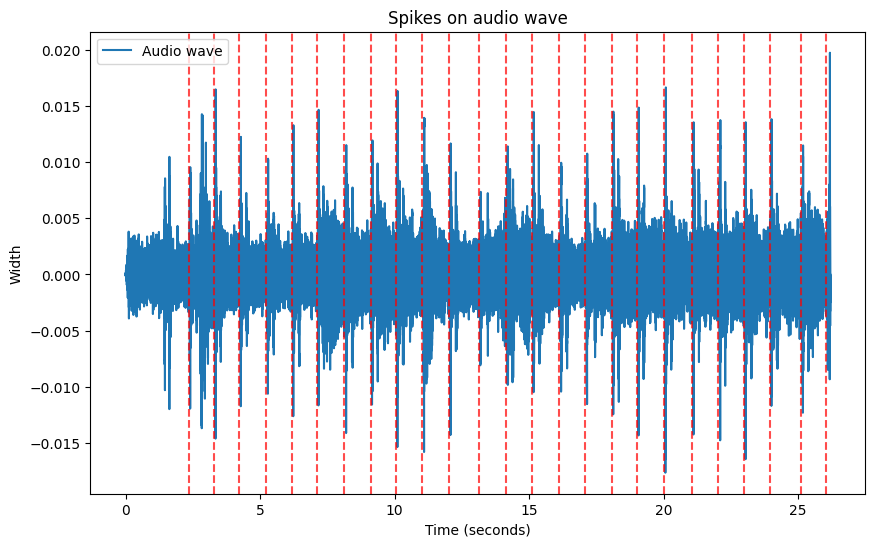

Valore del rumore di fondo: 0.0018025690913200379
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\T_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\T_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\T_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\T_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\T_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\T_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\T_split_7.wav
########################################################
Split 8 saved

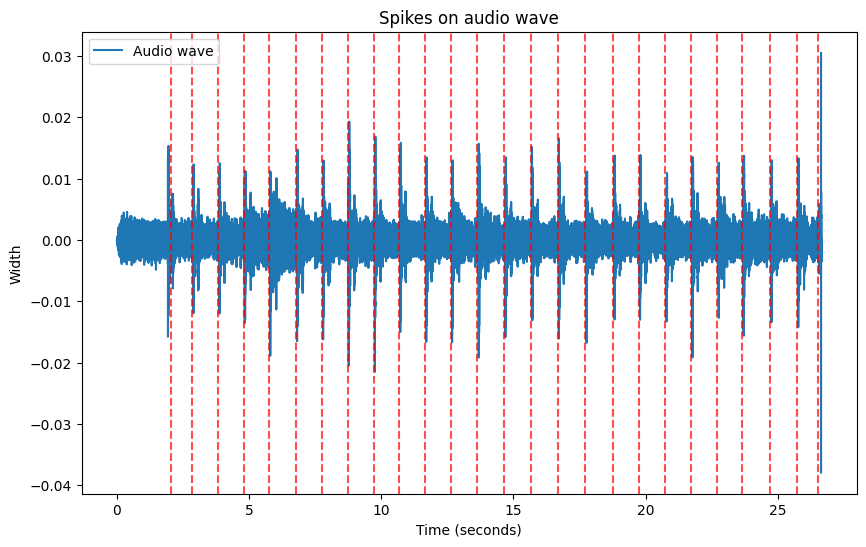

Valore del rumore di fondo: 0.00207124843634665
Numero di picchi sopra il threshold: 26
########################################################
Split 1 saved as archive/fold16/output_directory\U_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\U_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\U_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\U_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\U_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\U_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\U_split_7.wav
########################################################
Split 8 saved a

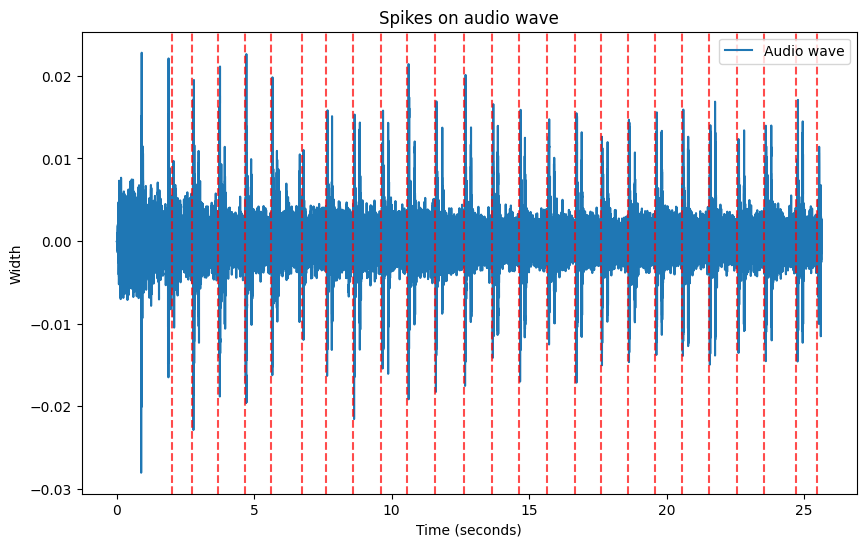

Valore del rumore di fondo: 0.0031662600338459015
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\V_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\V_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\V_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\V_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\V_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\V_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\V_split_7.wav
########################################################
Split 8 saved

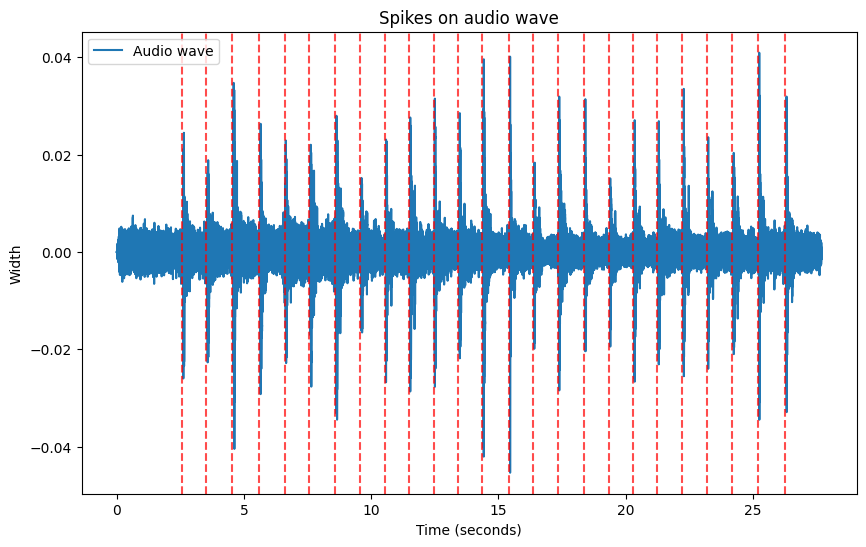

Valore del rumore di fondo: 0.0025793818747624755
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\W_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\W_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\W_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\W_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\W_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\W_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\W_split_7.wav
########################################################
Split 8 saved

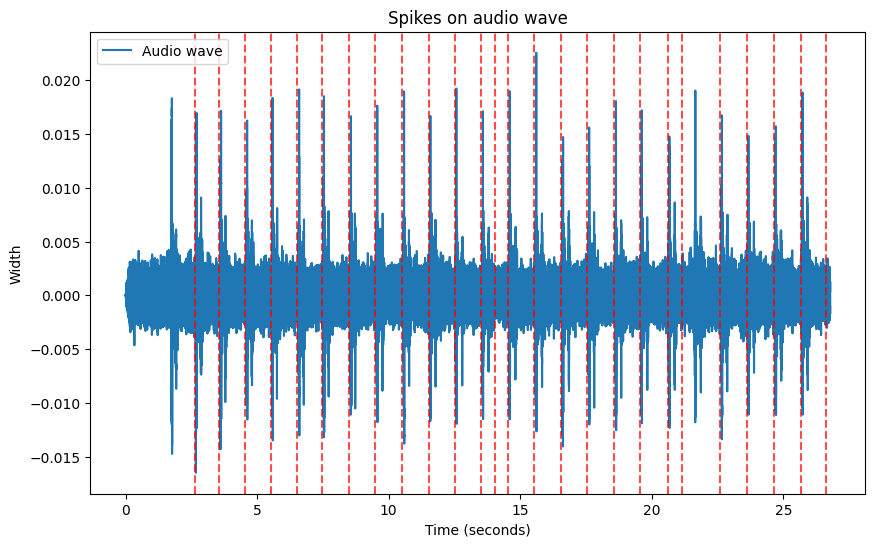

Valore del rumore di fondo: 0.001707471917849034
Numero di picchi sopra il threshold: 26
########################################################
Split 1 saved as archive/fold16/output_directory\X_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\X_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\X_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\X_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\X_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\X_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\X_split_7.wav
########################################################
Split 8 saved 

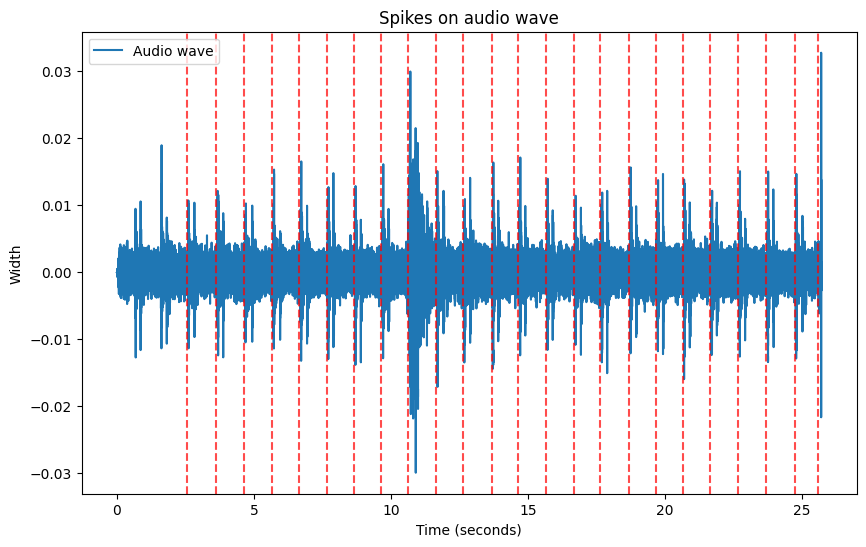

Valore del rumore di fondo: 0.0021234384728595615
Numero di picchi sopra il threshold: 24
########################################################
Split 1 saved as archive/fold16/output_directory\Y_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\Y_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\Y_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\Y_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\Y_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\Y_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\Y_split_7.wav
########################################################
Split 8 saved

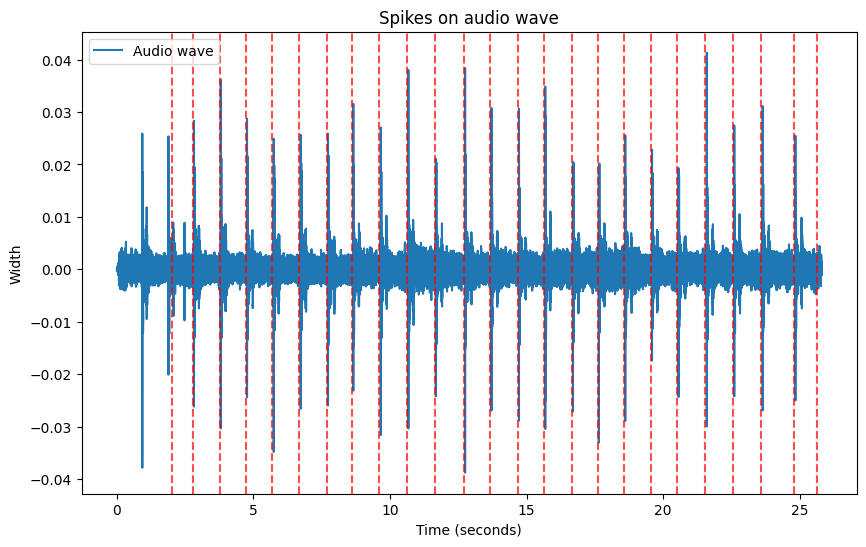

Valore del rumore di fondo: 0.001842664623633027
Numero di picchi sopra il threshold: 25
########################################################
Split 1 saved as archive/fold16/output_directory\Z_split_1.wav
########################################################
Split 2 saved as archive/fold16/output_directory\Z_split_2.wav
########################################################
Split 3 saved as archive/fold16/output_directory\Z_split_3.wav
########################################################
Split 4 saved as archive/fold16/output_directory\Z_split_4.wav
########################################################
Split 5 saved as archive/fold16/output_directory\Z_split_5.wav
########################################################
Split 6 saved as archive/fold16/output_directory\Z_split_6.wav
########################################################
Split 7 saved as archive/fold16/output_directory\Z_split_7.wav
########################################################
Split 8 saved 

In [23]:
input_directory = "archive/fold16/input"  # Replace with the path to your input directory

for filename in os.listdir(input_directory):
    if filename.endswith(".wav"):
        input_file = os.path.join(input_directory, filename)
        audio, sr = librs.load(input_file)
        # Calculate the time range to exclude the first and the last 0.1 seconds
        start_time = int(0.1 * sr)
        end_time = int(len(audio) - (0.1 * sr))
        # Trim the audio
        audio_cleared = audio[start_time:end_time]
        #recognize_peak(input_file, audio_cleared, sr)
        recognize_peak(input_file, audio, sr)
        #split_trim(input_file, peak_times, click_time, audio_cleared, sr)

In [24]:
input_wav = "./archive/fold16/output_directory/M_split_20.wav"
y, sr = librs.load(input_wav)
onset_env = librs.onset.onset_strength(y=y, sr=sr, hop_length=512, aggregate=np.median)
peaks = librs.util.peak_pick(onset_env, pre_max=3, post_max=3, pre_avg=3, post_avg=5, delta=0.5, wait=10)
peaks

array([ 3, 15], dtype=int64)

<Figure size 1000x600 with 0 Axes>

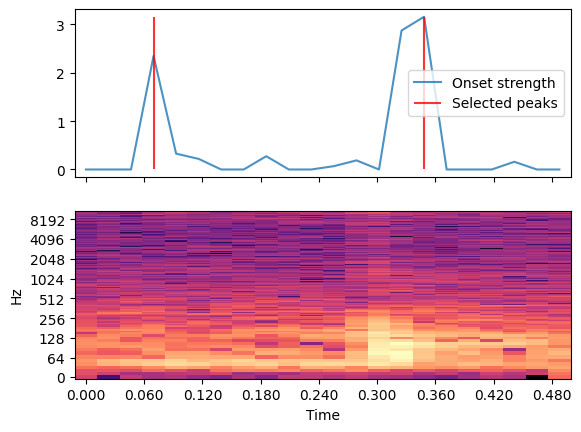

In [25]:
plt.figure(figsize=(10, 6))
times = librs.times_like(onset_env, sr=sr, hop_length=512)
fig, ax = plt.subplots(nrows=2, sharex=True)
D = np.abs(librs.stft(y))
librs.display.specshow(librs.amplitude_to_db(D, ref=np.max), y_axis='log', x_axis='time', ax=ax[1])
ax[0].plot(times, onset_env, alpha=0.8, label='Onset strength')
ax[0].vlines(times[peaks], 0, onset_env.max(), color='r', alpha=0.8, label='Selected peaks')
ax[0].legend(frameon=True, framealpha=0.8)
ax[0].label_outer()
plt.savefig("results/M_1_peak_01_secs.png")